### GAT for Puneet with Balanced Data ###

Read in graph from pickle file and confirm that it has attributes saved.

In [1]:
%load_ext autoreload
%autoreload 1

import pickle
import networkx as nx
import numpy as np

from simulation.Simulation_Constants import NUM_TRIALS, MAX_TRIAL_LENGTH, NUM_SITES, SITE_QUALITIES, NUM_AGENTS, QUORUM_THRESHOLD
from simulation.Simulation_Constants import TENSOR_WITH_TIMES
LOWER_CONFIDENCE = 20

file_name = "./pickle_networks/"
if TENSOR_WITH_TIMES:
    file_name += "tensor_with_times "
file_name += "NUM_TRIALS " + str(NUM_TRIALS)
file_name += " MAX_TRIAL_LENGTH " + str(MAX_TRIAL_LENGTH)
file_name += " NUM_SITES " + str(NUM_SITES)
file_name += " SITE_0_QUALITY " + str(SITE_QUALITIES[0]/255)
file_name += " SITE_1_QUALITY " + str(np.round(SITE_QUALITIES[1]/255,2))
file_name += " NUM_AGENTS " + str(NUM_AGENTS)
file_name += " QUORUM_THRESHOLD " + str(QUORUM_THRESHOLD)
print(file_name)


./pickle_networks/ NUM_TRIALS 1000 MAX_TRIAL_LENGTH 10000000 NUM_SITES 2 SITE_0_QUALITY 1.0 SITE_1_QUALITY 0.5 NUM_AGENTS 10 QUORUM_THRESHOLD 2.0 ARE THERE TRIANGLES


In [2]:
with open(file_name, 'rb') as f:
    G = pickle.load(f)

print(f"G has {len(G)} nodes.")
for node in {0,1,5,10}:
    print(f"node {node} is {G.nodes[node]}")

G has 1237 nodes.
node 0 is {'color': 0, 'tensor': [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0], 'num_successes': 481, 'num_trajectories': 1000}
node 1 is {'color': 0, 'tensor': [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0], 'num_successes': 481, 'num_trajectories': 1000}
node 10 is {'color': 0.5019607843137255, 'tensor': [0.5019607843137255, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 

Keep only the largest connected component.

In [4]:
largest_cc = max(nx.connected_components(G), key=len)
G = G.subgraph(largest_cc).copy()
print(f"The largest component of G has {len(G)} nodes.")
print(f"The network transitivity is {nx.transitivity(G)}.")
print(f"The average network clustering is is {nx.average_clustering(G)}.")
print(f"The number of nodes involving each node is {nx.triangles(G)}")

The largest component of G has 1237 nodes.
The network transitivity is 0.14679512913154022.
The average network clustering is is 0.09942647590507322.
The number of nodes involving each node is {0: 9, 1: 29, 2: 51, 3: 41, 4: 41, 5: 43, 6: 16, 7: 25, 8: 34, 9: 14, 10: 37, 11: 17, 12: 32, 13: 22, 14: 3, 15: 23, 16: 26, 17: 10, 18: 27, 19: 36, 20: 17, 21: 23, 22: 22, 23: 11, 24: 3, 25: 5, 26: 20, 27: 27, 28: 17, 29: 28, 30: 20, 31: 9, 32: 1, 33: 9, 34: 6, 35: 2, 36: 5, 37: 9, 38: 6, 39: 8, 40: 9, 41: 21, 42: 6, 43: 13, 44: 19, 45: 10, 46: 6, 47: 2, 48: 2, 49: 11, 50: 3, 51: 21, 52: 14, 53: 3, 54: 7, 55: 14, 56: 27, 57: 23, 58: 14, 59: 7, 60: 29, 61: 11, 62: 17, 63: 7, 64: 11, 65: 4, 66: 5, 67: 9, 68: 1, 69: 6, 70: 2, 71: 6, 72: 3, 73: 1, 74: 7, 75: 29, 76: 28, 77: 17, 78: 0, 79: 2, 80: 3, 81: 3, 82: 14, 83: 12, 84: 3, 85: 3, 86: 30, 87: 18, 88: 3, 89: 2, 90: 11, 91: 12, 92: 1, 93: 5, 94: 11, 95: 6, 96: 5, 97: 19, 98: 8, 99: 11, 100: 15, 101: 6, 102: 11, 103: 26, 104: 15, 105: 4, 106: 5, 10

Read graph into pytorch geometric data object.

In [5]:
import torch_geometric.transforms
from torch_geometric.utils import from_networkx
from torch import Tensor
from sklearn.model_selection import train_test_split
import torch
import torch_geometric.data

def convert_to_pytorch_geometric(G) -> torch_geometric.data:
    
    # Step 0: Create a new graph where the tensor is the node feature
    H = nx.Graph()
    for node in G.nodes:
        H.add_node(node, feature = G.nodes[node]["tensor"])

    # Step 1: Add edge by node mapping for each edge in graph
    for edge in G.edges:
        H.add_edge(edge[0],edge[1])

    # Step 2: Create pytorch object for graph H
    return from_networkx(H)
    
data = convert_to_pytorch_geometric(G)
print(data)
print(f"Feature of first node is {data.feature[0]}")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch_geometric/typing.py:110: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: dlopen(/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch_sparse/_version_cpu.so, 0x0006): Symbol not found: __ZN3c1017RegisterOperatorsD1Ev
  Referenced from: <594D1ECB-C389-3CE8-8CA8-529E73641ADB> /Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch_sparse/_version_cpu.so
  Expected in:     <2A8DB508-8AAF-3FF1-BDFE-9EF17CC2B482> /Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/lib/libtorch_cpu.dylib
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "


Data(edge_index=[2, 106162], feature=[21398, 100], num_nodes=21398)
Feature of first node is tensor([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])


In [6]:
# Step 3: Tell the data structure how many nodes are in the graph
data.num_nodes = len(G.nodes)
print(f"Number of nodes is {data.num_nodes}")

#data.num_node_features = len(data.feature[0])
#print(f"Number of nodes is {data.num_node_features}")
#data.feature = Tensor(data.feature).to(torch.float)


Number of nodes is 21398


In [7]:
# Step 4: Assign each node to a class based on its success probability
bins = [0, .25, .5, .75, 1.0]
#bins = [0, 0.5, 1.0]
bin_dict: dict[float: str] = dict()
for i in range(len(bins)-1):
    bin_name = str(int(np.round(bins[i]*100,0))) + "% -- " + str(int(np.round(bins[i+1]*100,0))) + "%"
    bin_dict[bins[i]] = bin_name
print(bin_dict)

def __get_node_class__(G,node):
    success_rate = G.nodes[node]["num_successes"] / G.nodes[node]["num_trajectories"]
    for i in range(len(bins)-1):
        if success_rate <= bins[i+1]: return i

labels = [__get_node_class__(G,node) for node in G.nodes]
data.y = Tensor(labels).to(torch.long)
data.num_classes = 4
print(f"Number of classes is {data.num_classes}")
print(f"Data is {data}")


{0: '0% -- 25%', 0.25: '25% -- 50%', 0.5: '50% -- 75%', 0.75: '75% -- 100%'}
Number of classes is 4
Data is Data(edge_index=[2, 106162], feature=[21398, 100], num_nodes=21398, y=[21398], num_classes=4)


In [8]:
# Step 5: Create a list of nodes to exclude based on infrequent visits
exclude_nodes = []
for node in G.nodes:
    if G.nodes[node]["num_trajectories"] < LOWER_CONFIDENCE : exclude_nodes.append(node) # TODO: fix magic number 10
exclude_nodes = [] ### Don't exclude anything.
print(f"Excluding {exclude_nodes}")

Excluding []


In [9]:
def __split_data__(G, data, exclude_nodes):
    indices = [i for i in G.nodes if i not in exclude_nodes]
    train_indices, test_indices = train_test_split(indices, test_size=0.2, random_state=42)
    print(f"Training on {train_indices}")
    print(f"Testing on {test_indices}")
    # Create masks
    train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    train_mask[train_indices] = 1
    test_mask[test_indices] = 1
    data.train_mask = Tensor(train_mask)
    data.test_mask = Tensor(test_mask)
    print(f"Train mask is {train_mask}")
    print(f"Test mask is {test_mask}")
    return data.train_mask, data.test_mask

# Step 6: Create train-test split. Code from ChatGPT
data.train_mask, data.test_mask = __split_data__(G, data, exclude_nodes)
print(data)
  

Training on [1959, 14891, 15969, 8611, 10346, 11952, 14090, 2541, 5998, 4779, 17723, 12202, 930, 10859, 16734, 6075, 17056, 12257, 8487, 12005, 16337, 11807, 8647, 10836, 17012, 20437, 14395, 1464, 17561, 4932, 10497, 14593, 6024, 21360, 5934, 5928, 10094, 14583, 19636, 17843, 1837, 16966, 11057, 9357, 19766, 49, 15257, 18953, 10105, 20469, 12663, 14611, 16215, 10263, 19275, 20783, 12054, 20487, 14958, 18127, 10011, 3698, 7026, 3451, 16439, 19957, 1557, 17385, 17254, 7223, 7015, 16677, 16983, 19751, 14624, 8187, 16290, 13520, 12262, 16979, 20168, 19717, 2157, 9210, 19022, 11579, 18484, 17463, 16418, 2814, 1697, 6920, 16168, 9646, 1066, 6909, 2439, 7883, 9773, 13471, 19600, 11342, 2782, 7284, 3934, 5286, 2039, 2360, 5673, 16354, 6492, 14053, 6389, 8342, 18696, 5337, 16059, 9498, 17381, 11881, 8746, 20411, 3287, 19781, 14041, 13175, 9295, 11839, 12863, 20179, 11012, 21067, 9889, 17698, 9978, 2046, 19791, 14692, 6613, 18664, 10365, 11681, 18979, 4935, 20095, 3059, 11288, 20892, 9239, 6098

I'd like to see a histogram of how much of the data falls into each class. I expect the data to be biased.

{0, 1, 2, 3}
(0.0, 1.0)
[0.375, 1.125, 1.875, 2.625]
[0.   0.75 1.5  2.25 3.  ]


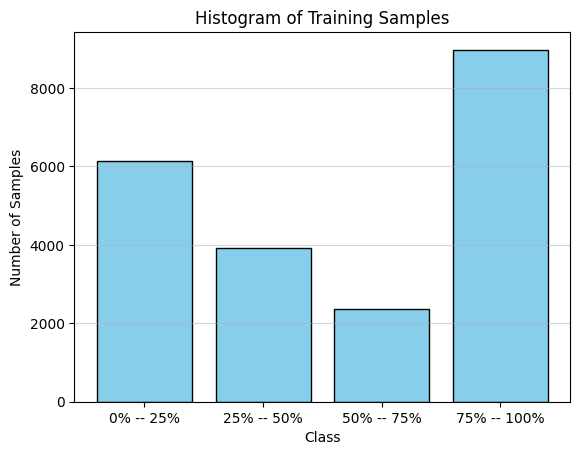

In [10]:
import matplotlib.pyplot as plt
classes = data.y.detach().numpy()
print(set(classes))
num_classes = len(set(classes))
plt.figure()
ax = plt.gca()
x_lim = ax.get_xlim()
print(x_lim)
bar_width = 0.8*(x_lim[1] - x_lim[0])
h =plt.hist(classes, bins=num_classes, range = [min(set(classes)), max(set(classes))], 
         rwidth=bar_width, align='mid', color='skyblue', edgecolor='black')
bin_edges = h[1]
ticks = [bin_edges[i] + (bin_edges[i+1] - bin_edges[i])/2 for i in range(num_classes)]
print(ticks)
print(bin_edges)
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.title('Histogram of Training Samples')
plt.xticks(ticks = ticks, labels = bin_dict.values())
plt.grid(axis='y', alpha=0.5)
plt.show()

Repeat but with pie chart just for kicks and giggles. See minute 3:13 from this [tutorial](https://www.youtube.com/watch?v=o_mnbn8nFL8)

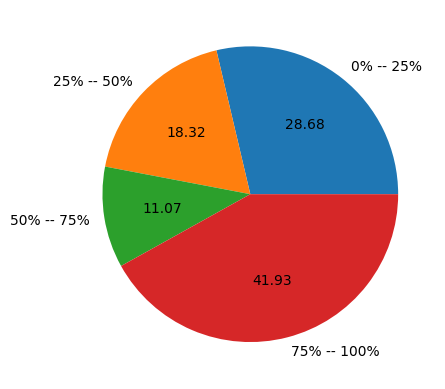

In [11]:
fig, ax = plt.subplots()
#print(labels)
#print(classes)
#print(h)
_ = ax.pie(h[0]/sum(h[0]), autopct="%.2f", labels = bin_dict.values())

### Graph Autoencoder ###

The most simple place to begin is to create a graph autoencoder to see what kinds of structures can be pulled from the graph when the tensors are the graph features. I'll implement a GAE with two hidden layers.

In [12]:
from torch_geometric.nn import GAE
import torch
from torch_geometric.nn import GCNConv
class Encoder(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.hidden_layer_1 = GCNConv(in_channels, 8 * out_channels)
        self.hidden_layer_2 = GCNConv(8 * out_channels, out_channels)        
    def forward(self, x, edge_index):
        h1 = self.hidden_layer_1(x, edge_index)
        z = self.hidden_layer_2(h1, edge_index)
        return z

Specify the number of output channels, instantiate the model, and specify the optimizer.

In [13]:
if 'model' in globals(): del model
out_channels = 4
num_features = torch.Tensor.size(data.feature)[1]
print(f"There are {num_features} features")
model = GAE(Encoder(num_features, out_channels))
print(model)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


There are 100 features
GAE(
  (encoder): Encoder(
    (hidden_layer_1): GCNConv(100, 32)
    (hidden_layer_2): GCNConv(32, 4)
  )
  (decoder): InnerProductDecoder()
)


Train the GAE.

In [14]:
def train_with_features(data, model):
    optimizer.zero_grad()  # Clear gradients.
    z = model.encode(data.feature, data.edge_index)  # Perform a single forward pass.
    loss = model.recon_loss(z, data.edge_index)
    loss.backward()  # Derive gradients.
    optimizer.step()  # Update parameters based on gradients.
    return loss, z

epochs = 2000
#for epoch in range(1, epochs):
#    if epoch%20 == 0: print(f"loss = {loss} on epoch = {epoch}")
#    loss, z = train_with_features(data, model)

Inspect the embedding. Color the nodes by their success probability.

In [15]:
from sklearn.manifold import TSNE
import matplotlib as mpl
def visualize(Z, colors, alpha):
    z = TSNE(n_components=2).fit_transform(Z)
    plt.scatter(z[:, 0], z[:, 1], c=colors, alpha = alpha, s=10)
    pos = {node: (z[node,0], z[node,1]) for node in range(len(z))}
    return pos

Z = model.encode(data.feature, data.edge_index).detach().numpy()
cmap = mpl.colormaps['cool']
max_confidence = max([G.nodes[node]["num_trajectories"] for node in G.nodes])
colors = [cmap(G.nodes[node]["num_successes"]/G.nodes[node]["num_trajectories"]) for node in G.nodes]
alpha = [G.nodes[node]["num_trajectories"] / max_confidence for node in G.nodes]
#pos = visualize(Z, colors, alpha)

It looks like there is some structure in the sense that nodes with high confidence are grouped together. Note that there are very few nodes that fail that are also high confidence. 

---

### GCN-Based Encoding ###

Let's now train a GCN to learn the labels of the nodes and see if we get useful clusters in the resulting encoding.

In [16]:
if 'model' in globals(): del model
print(data.y)
print(data.edge_index)

tensor([1, 1, 1,  ..., 3, 3, 3])
tensor([[    0,     0,     0,  ..., 21396, 21397, 21397],
        [    1,    36,    69,  ..., 21397,  1680, 21396]])


Create a visualization function to help us see which nodes end up where.

In [17]:
def visualize(h, title = "Scaatter Plot"):
    colorlist = ['#e41a1c', '#984ea3', '#377eb8', '#4daf4a', '#ff7f00', '#ffff33', '#a65628']
    z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())

    plt.figure(figsize=(10,10))
    plt.xticks([])
    plt.yticks([])
    alpha = [0.1 if G.nodes[node]["num_trajectories"] < LOWER_CONFIDENCE else 0.8 for node in G.nodes]
    
    for class_number in range(data.num_classes):
        index_list = extract_nodes_by_class(data.y,class_number)
        #a = [alpha[i] for i in index_list]
        #plt.scatter(z[index_list, 0], z[index_list, 1], s=10, c=colorlist[class_number], alpha = a)
        plt.scatter(z[index_list, 0], z[index_list, 1], s=10, c=colorlist[class_number], alpha = 0.7)

    #plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    _ = plt.legend(bin_dict.values(),bbox_to_anchor=(1, 1), loc='upper left')
    plt.title(title)
    plt.show()

def extract_nodes_by_class(data,class_number):
    index_list = []
    for index, item in enumerate(data):
        if data[index] == class_number:
            index_list.append(index)
    return index_list

Create a two layer neural network with a rectified linear unit squashing function and dropout.

In [18]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self, num_node_features, hidden_channels):
        super().__init__()
        torch.manual_seed(1234567)
        self.hidden_layer_1 = GCNConv( num_node_features, 4 * hidden_channels )
        self.hidden_layer_2 = GCNConv( 4 * hidden_channels, hidden_channels )
        self.output = GCNConv( hidden_channels, data.num_classes )
 
    def forward(self, x, edge_index):
        x = self.hidden_layer_1(x, edge_index)
        x = x.relu()
        #x = F.dropout(x, p=0.5, training=self.training)
        x = self.hidden_layer_2(x, edge_index)
        x = x.relu()
        #x = F.dropout(x, p=0.2, training=self.training)
        x = self.output(x, edge_index)
        return x 

model = GCN(num_node_features = data.feature[0].size(0), hidden_channels=16)
print(model)

GCN(
  (hidden_layer_1): GCNConv(100, 64)
  (hidden_layer_2): GCNConv(64, 16)
  (output): GCNConv(16, 4)
)


Set up training and testing.

In [19]:
if 'model' in globals(): del model
model = GCN(num_node_features = data.feature[0].size(0), hidden_channels=16)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

def train():
      model.train()
      optimizer.zero_grad()  # Clear gradients.
      out = model(data.feature, data.edge_index)  # Perform a single forward pass.
      loss = criterion(out[data.train_mask], data.y[data.train_mask])  # Compute the loss solely based on the training nodes.
      loss.backward()  # Derive gradients.
      optimizer.step()  # Update parameters based on gradients.
      return loss

def test():
      model.eval()
      out  = model(data.feature, data.edge_index)
      pred = out.argmax(dim=1)  # Use the class with highest probability.
      test_correct = pred[data.test_mask] == data.y[data.test_mask]  # Check against ground-truth labels.
      test_acc = int(test_correct.sum()) / int(data.test_mask.sum())  # Derive ratio of correct predictions.
      return test_acc

Train and inspect loss function.

In [20]:
epochs = 4000
#for epoch in range(1, epochs):
#    loss = train()
#    if epoch%20 == 0:
#        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}')

Let's inspect the embedding.

In [21]:
#embedding = model(data.feature, data.edge_index)
#visualize(embedding, title = "3-level GCN-based Embedding")

There is some structure evident when we use time-based tensors, but not when we don't use time-based tensors. When we don't use time-based tensors, it appears to be emphasizing graph structure to the detriment of success or failure. I could address this by using fewer layers, but I'm going to try using a graph attention network first.

---

### Graph Attention Network ###

Let's try a graph attention network since these networks tend to focus on the part of the features that are most important. This might counterbalance the strong graph effects.

Import relevant modules and define an accuracy function to help quantify how well the model is learning.

In [22]:
from torch_geometric.nn import GATv2Conv
from torch.nn import Linear

def accuracy(y_pred, y_true):
    return torch.sum(y_pred==y_true) / len(y_true)

Create a GAT with two GAT layers followed by a linear layer. Force the linear layer through a log softmax operator so that it has to choose a class.

In [23]:
class GAT(torch.nn.Module):
    def __init__(self, dim_in, dim_h, dim_out, heads = 8):
        super().__init__()
        self.gat1 = GATv2Conv(dim_in, dim_h, heads = heads)
        self.gat2 = GATv2Conv(dim_h*heads, dim_out, heads = 1)
        self.linear = Linear(dim_out, dim_out)
    
    def forward(self, x, edge_index):
        h = F.dropout(x, p=0.6, training = self.training)
        h = self.gat1(h, edge_index)
        h = F.elu(h)
        h = F.dropout(h, p=0.6, training = self.training)
        h = self.gat2(h, edge_index)
        h = F.elu(h)
        embedding = h #self.linear(h)
        h = self.linear(h)
        out = F.log_softmax(h, dim=1)
        return out, embedding # both the learned class and the embedding are returned.
    
    def fit(self, data, epochs):
        optimizer = torch.optim.Adam(self.parameters(), lr=0.01, weight_decay=0.01)
        criterion = torch.nn.CrossEntropyLoss()

        self.train()
        for epoch in range(epochs+1):
            optimizer.zero_grad()
            out, _ = self(data.feature, data.edge_index)
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
            acc = accuracy(out[data.train_mask].argmax(dim=1), data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            # Every now and then print out progress reports
            if epoch % 20 == 0:
                test_loss = criterion(out[data.test_mask], data.y[data.test_mask])
                test_acc = accuracy(out[data.test_mask].argmax(dim=1), data.y[data.test_mask])
                print(f"Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc: {acc*100:>5.2f}% | Test Loss {test_loss: .2f} | Test Acc: {test_acc*100:.2f}%")
            

    @torch.no_grad()
    def test(self, data):
        self.eval()
        out, _ = self(data.feature, data.edge_index)
        acc = accuracy(out.argmax(dim=1)[data.test_mask], data.y[data.test_mask])
        return acc


Create the GAT and run for a handful of epochs.

In [24]:
if 'gat' in globals(): del gat
num_features = data.feature[0].size(0)
print(f"There are {num_features} features in the data")
print(f"There are {data.num_classes} classes in the data")
gat = GAT(num_features, 32, data.num_classes)
print(gat)


There are 100 features in the data
There are 4 classes in the data
GAT(
  (gat1): GATv2Conv(100, 32, heads=8)
  (gat2): GATv2Conv(256, 4, heads=1)
  (linear): Linear(in_features=4, out_features=4, bias=True)
)


In [25]:
#gat.fit(data, epochs = 300)

Inspect the embedding.

In [26]:
#gat.eval()
#out, embedding = gat(data.feature, data.edge_index)
#visualize(embedding, title = "2-level GAT-based Embedding")

### 3-layer GAT ###

Notice that I'm using a weighted cross entropy loss function. See [compute class weight](https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html) and the [discussion here](https://datascience.stackexchange.com/questions/52627/why-class-weight-is-outperforming-oversampling).

In [27]:
from sklearn.utils.class_weight import compute_class_weight
class GAT(torch.nn.Module):
    def __init__(self, dim_in, dim_h, dim_out, heads = 8):
        super().__init__()
        self.gat1 = GATv2Conv(dim_in, dim_h*4, heads = heads)
        self.gat2 = GATv2Conv(dim_h*4*heads, dim_h*2, heads = heads)
        self.gat3 = GATv2Conv(dim_h*2*heads, dim_h, heads = 1)
        self.output = Linear(dim_h, dim_out)
    
    def forward(self, x, edge_index):
        h = F.dropout(x, p=0.6, training = self.training)
        h = self.gat1(h, edge_index)
        h = F.elu(h)
        h = F.dropout(h, p=0.6, training = self.training)
        h = self.gat2(h, edge_index)
        h = F.elu(h)
        h = F.dropout(h, p=0.6, training = self.training)
        h = self.gat3(h, edge_index)
        h = F.elu(h)
        embedding = h
        out = self.output(h)
        out = F.log_softmax(out, dim=1)
        return out, embedding # both the learned class and the embedding are returned.
    
    def fit(self, data, epochs):
        # Compute weights
        y = data.y.detach()
        class_weight = compute_class_weight(class_weight="balanced", classes=np.unique(y), y=y.numpy())
        class_weight = torch.tensor(class_weight, dtype=torch.float32)
        print(f"The class weighting is {class_weight}")

        optimizer = torch.optim.Adam(self.parameters(), lr=0.01, weight_decay=0.01)
        criterion = torch.nn.CrossEntropyLoss(weight=class_weight, reduction='mean')
        #criterion = torch.nn.CrossEntropyLoss()

        print(f"Beginning training. The number of classes in the data is {np.unique(data.y[data.train_mask].detach().numpy())}")

        self.train()
        for epoch in range(epochs+1):
            optimizer.zero_grad()
            out, _ = self(data.feature, data.edge_index)
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
            acc = accuracy(out[data.train_mask].argmax(dim=1), data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            # Every now and then print out progress reports
            if epoch % 20 == 0:
                test_loss = criterion(out[data.test_mask], data.y[data.test_mask])
                test_acc = accuracy(out[data.test_mask].argmax(dim=1), data.y[data.test_mask])
                print(f"Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc: {acc*100:>5.2f}% | Test Loss {test_loss: .2f} | Test Acc: {test_acc*100:.2f}%")
            

    @torch.no_grad()
    def test(self, data):
        self.eval()
        out, _ = self(data.feature, data.edge_index)
        acc = accuracy(out.argmax(dim=1)[data.test_mask], data.y[data.test_mask])
        return acc


Train 3-level GAT

In [28]:
if 'gat' in globals(): del gat
num_features = data.feature[0].size(0)
gat = GAT(dim_in = num_features, dim_h = 8, dim_out = data.num_classes, heads = 8) # def __init__(self, dim_in, dim_h, dim_out, weight, heads = 8):
print(gat)


GAT(
  (gat1): GATv2Conv(100, 32, heads=8)
  (gat2): GATv2Conv(256, 16, heads=8)
  (gat3): GATv2Conv(128, 8, heads=1)
  (output): Linear(in_features=8, out_features=4, bias=True)
)


In [29]:
print(np.unique(data.y.detach().numpy()))
gat.fit(data, epochs = 300)

[0 1 2 3]
The class weighting is tensor([0.8715, 1.3647, 2.2591, 0.5962])
Beginning training. The number of classes in the data is [0 1 2 3]
Epoch   0 | Train Loss: 1.495 | Train Acc: 23.71% | Test Loss  1.49 | Test Acc: 24.02%
Epoch  20 | Train Loss: 1.174 | Train Acc: 49.07% | Test Loss  1.17 | Test Acc: 48.60%
Epoch  40 | Train Loss: 1.119 | Train Acc: 49.78% | Test Loss  1.12 | Test Acc: 49.67%
Epoch  60 | Train Loss: 1.117 | Train Acc: 56.39% | Test Loss  1.12 | Test Acc: 57.24%
Epoch  80 | Train Loss: 1.029 | Train Acc: 58.22% | Test Loss  1.04 | Test Acc: 58.95%
Epoch 100 | Train Loss: 1.024 | Train Acc: 58.31% | Test Loss  1.02 | Test Acc: 58.46%
Epoch 120 | Train Loss: 1.070 | Train Acc: 50.24% | Test Loss  1.08 | Test Acc: 50.05%
Epoch 140 | Train Loss: 1.018 | Train Acc: 57.44% | Test Loss  1.02 | Test Acc: 58.36%
Epoch 160 | Train Loss: 1.024 | Train Acc: 57.54% | Test Loss  1.03 | Test Acc: 57.41%
Epoch 180 | Train Loss: 1.007 | Train Acc: 57.81% | Test Loss  1.00 | Test A

Visually inspect embedding

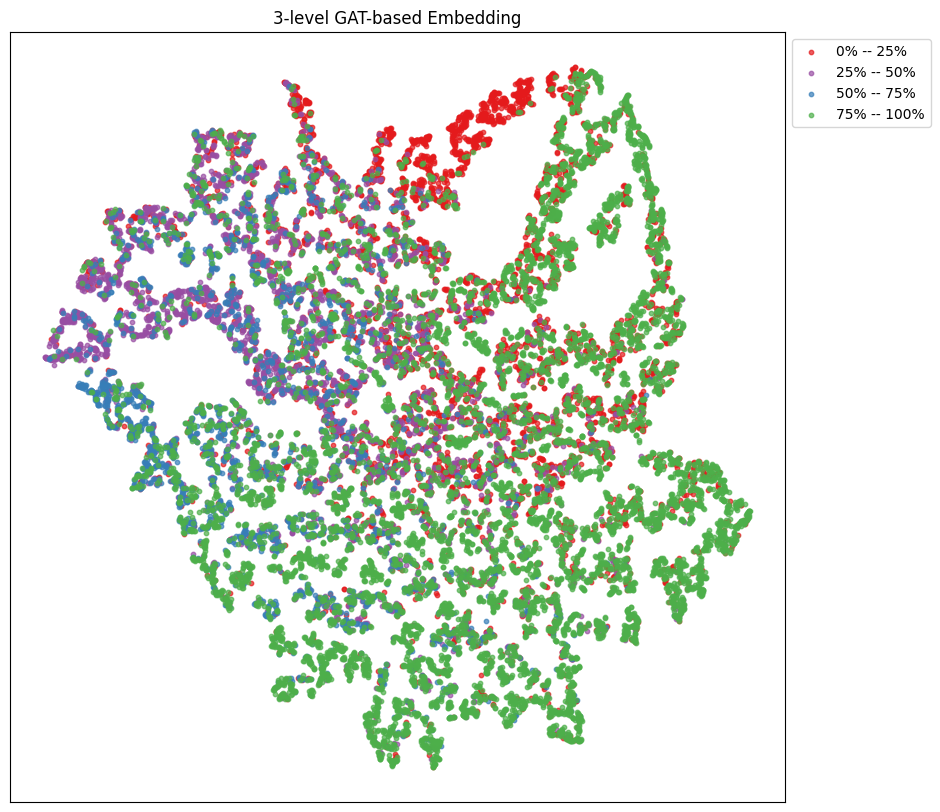

In [30]:
gat.eval()
out, embedding = gat(data.feature, data.edge_index)
visualize(embedding, title = "3-level GAT-based Embedding")

---

### Classifier Development and Accuracy ###

Naive k-means clustering doesn't use the class of the node so I will explore a different classification algorithm. The classification algorithm will take the embedding plus the node labels and form a decision rule. I'll first try to use _Gradient Boosted Regression Trees_ following the [tutorial](https://www.youtube.com/watch?v=IXZKgIsZRm0&t=798s) from Peter Prettenhofer. Since I want to learn how the algorithm works, I'll work through the math as part of this notebook.

__Functional Gradient Descent__

Let the vector ${\mathbf x}_i$ denote the embedding for node $i$. Let the label $y_i$ denote the success probability associated with node $i$. The goal is to find a function $f$ such that for each node $y_i \approx f({\mathbf x}_i)$.

Eventually, I'll want to have the loss function be cross entropy, but for now consider squared error. Define the loss as

$$ L\big(y_i, f({\mathbf x}_i)\big) = \big(y_i - f({\mathbf x}_i)\big)^2 $$

Define the _residual_ for node $i$ as 

$$r_i = y_i - f({\mathbf x}_i)$$

Notice how the residual approximates the $i^{\rm th}$ partial derivative in the gradient:

$$ \frac{\partial L\big(y_i, f({\mathbf x}_i)\big)}{\partial f({\mathbf x}_i)} = 2\big(y_i - f({\mathbf x}_i)\big) \approx \big(y_i - f({\mathbf x}_i)\big) $$

So, to improve the estimator $f$ we take a "baby step" in the direction of the gradient, which is the same as taking a baby step in the direction of the residual.

__Boosting__

My understanding of boosting is that we create a cascade of estimators. The first estimator does just what is described above, but the second estimator tries to learn the residual. Let the superscript $^(j)$ denote the $j^{\rm th}$ estimator. Thus, the second estimator is

$$ L^{(2)}\big(r_i^{(1)} - f^{(2)}({\mathbf x}_i)\big) = \big( r^{(1)}_i - f^{(2)}({\mathbf x}_i)\big)^2 $$

So, to improve the estimator $f^{(2)}$ we take a "baby step" in the direction of the gradient of $L^{(2)}$, which is the same as taking a baby step in the direction of the second residual 

$$r_i^{(2)} = r_i^{(1)} - f^{(2)}({\mathbf x}_i)$$

I don't understand how the various functional gradients are sequenced, like do you first learn $f^{(1)}$ through gradient descent and then learn $f^{(2)}$ through gradient descent and so on?

__Gradient Boosted Regression Trees__

GBRTs estimate the functions $f^{(j)}$ using decision trees. I'm going to use the example code from minute 14:39 of the tutorial.

In [31]:
from sklearn.ensemble import GradientBoostingClassifier
X = embedding.detach().cpu().numpy()
y = data.y.detach().numpy()

print(X)
print(y)

[[ 0.64071757  0.759027    1.3845139  ...  0.0652096   0.5690743
   0.6604225 ]
 [ 0.50671303  0.78251857  1.4176863  ...  0.15450439  0.5609314
   0.73702836]
 [ 0.5143722   0.77977633  1.4161773  ...  0.15476409  0.55885804
   0.7329451 ]
 ...
 [ 2.0273209   0.16087475  0.48518386 ... -0.57531095  0.4081108
  -0.36730862]
 [ 2.2150607   0.17829818  0.5327162  ... -0.61632097  0.4433337
  -0.40137297]
 [ 2.192454    0.22187684  0.6065308  ... -0.6074187   0.46419728
  -0.3703493 ]]
[1 1 1 ... 3 3 3]


In [32]:
est = GradientBoostingClassifier(n_estimators=200, max_depth=3) # n_estimators is the number of trees and max_depth is the maximum depth of any individual tree.
est.fit(X,y)

GradientBoostingClassifier(n_estimators=200)

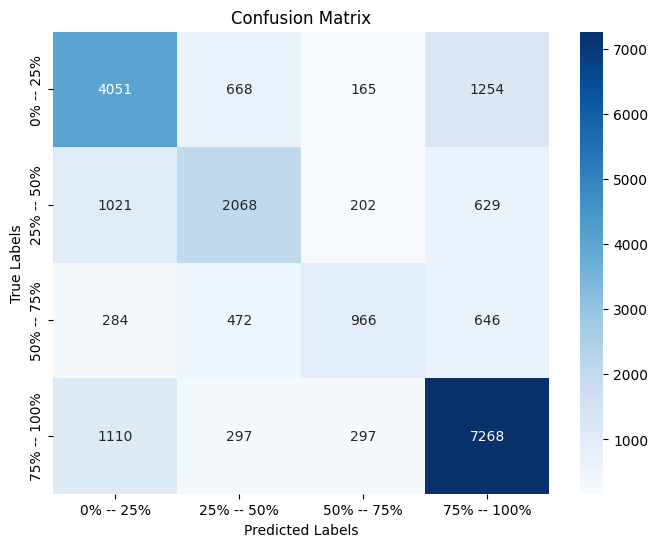

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

y_pred = est.predict(X)
cm = confusion_matrix(y, y_pred)#, labels = bin_dict.values())
CLIST =  bin_dict.values()

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=CLIST, yticklabels=CLIST)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show() 


Use a validation set that only includes nodes that have been visited more than the threshold amount.

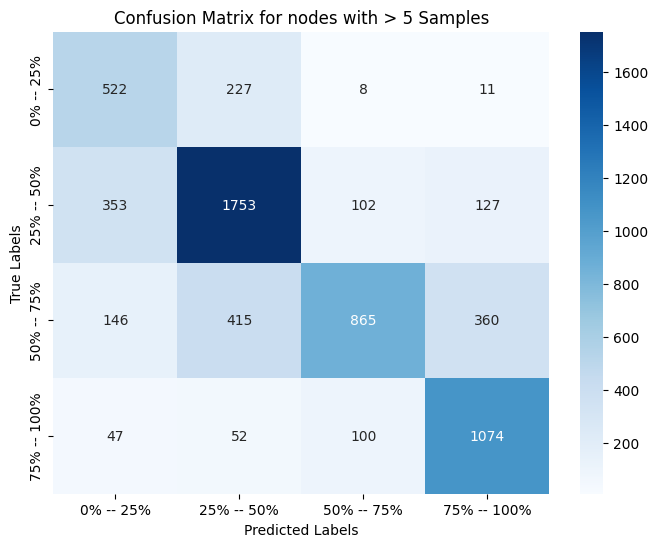

In [34]:
X_confident = [X[node] for node in G.nodes if G.nodes[node]["num_trajectories"] >= 5]
y_confident = [y[node] for node in G.nodes if G.nodes[node]["num_trajectories"] >= 5]
y_pred = est.predict(X_confident)
cm = confusion_matrix(y_confident, y_pred)#, labels = bin_dict.values())
CLIST =  bin_dict.values()

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=CLIST, yticklabels=CLIST)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for nodes with > 5 Samples')
plt.show() 

Visually inspect where the classifier agrees with the data and where it doesn't.

In [35]:
def visualize_with_shapes(X, y_pred):
    colorlist = ['#e41a1c', '#984ea3', '#377eb8', '#4daf4a', '#ff7f00', '#ffff33', '#a65628']
    z = TSNE(n_components=2).fit_transform(X)

    shape_map = ['s','o','v','x']
    shapes = [shape_map[i] for i in y_pred]

    plt.figure(figsize=(10,10))
    plt.xticks([])
    plt.yticks([])

    legend_list = []

    for class_number in range(num_classes):
        cluster_number = 0
        if class_number == 0: legend_item = "0% -- 25% successes"
        elif class_number == 1: legend_item = "25% -- 50% successes" 
        elif class_number == 2: legend_item = "50% -- 75% successes" 
        else: legend_item = "75% -- 100% successes" 
        for shape in shape_map:
            legend_list.append(legend_item + f" cluster {cluster_number}")
            cluster_number += 1
            index_list = extract_nodes_by_class_and_shape(data.y, shapes, class_number, shape)
            plt.scatter(z[index_list, 0], z[index_list, 1], s=10, c=colorlist[class_number], marker = shape, alpha = 0.7)


    #plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    _ = plt.legend(legend_list,bbox_to_anchor=(1, 1), loc='upper left')
    plt.show()

def extract_nodes_by_class_and_shape(data,shapes, class_number, shape):
    index_list = []
    for index, _ in enumerate(data):
        if data[index] == class_number and shapes[index] == shape:
            index_list.append(index)
    return index_list

#visualize_with_shapes(X, y_pred)

### Graph Autoencoder revisited ###

Now that I know that a three-level GAT classifier yields decent clusters, I want to revisit what can and can't be done with the graph autoencoder. The reason for doing this is so that I have some sense of what can and can't be done with GraphSAGE, which is essentially an inductive graph autoencoder. 

Create a new autoencoder with an architecture very similar to the GAT architecture.

In [36]:
class Encoder(torch.nn.Module):
    def __init__(self, dim_in, dim_h):
        super().__init__()
        self.hidden_layer_1 = GCNConv(dim_in, 4 * dim_h)
        self.hidden_layer_2 = GCNConv(4 * dim_h, 2 * dim_h)
        self.hidden_layer_3 = GCNConv(2 * dim_h, dim_h)
    def forward(self, x, edge_index):
        h = F.dropout(x, p=0.6, training = self.training)
        h = self.hidden_layer_1(h, edge_index)
        h = F.elu(h)
        h = F.dropout(h, p=0.6, training = self.training)
        h = self.hidden_layer_2(h, edge_index)
        h = F.elu(h)
        h = F.dropout(h, p=0.6, training = self.training)
        h = self.hidden_layer_3(h, edge_index)
        return h


Instatiate autoencoder

In [37]:
if 'gae' in globals(): del gae
num_features = data.feature[0].size(0)
gae = GAE(Encoder(dim_in = num_features, dim_h = 8))
print(gae)

GAE(
  (encoder): Encoder(
    (hidden_layer_1): GCNConv(100, 32)
    (hidden_layer_2): GCNConv(32, 16)
    (hidden_layer_3): GCNConv(16, 8)
  )
  (decoder): InnerProductDecoder()
)


Train and visualize

Epoch = 0. Loss = 5.150000095367432
Epoch = 20. Loss = 1.1799999475479126
Epoch = 40. Loss = 1.090000033378601
Epoch = 60. Loss = 1.0399999618530273
Epoch = 80. Loss = 1.0199999809265137
Epoch = 100. Loss = 1.0
Epoch = 120. Loss = 0.9900000095367432
Epoch = 140. Loss = 0.9900000095367432
Epoch = 160. Loss = 0.9800000190734863
Epoch = 180. Loss = 0.9700000286102295
Epoch = 200. Loss = 0.9700000286102295
Epoch = 220. Loss = 0.9700000286102295
Epoch = 240. Loss = 0.9700000286102295
Epoch = 260. Loss = 0.9700000286102295
Epoch = 280. Loss = 0.9599999785423279
Epoch = 300. Loss = 0.9700000286102295


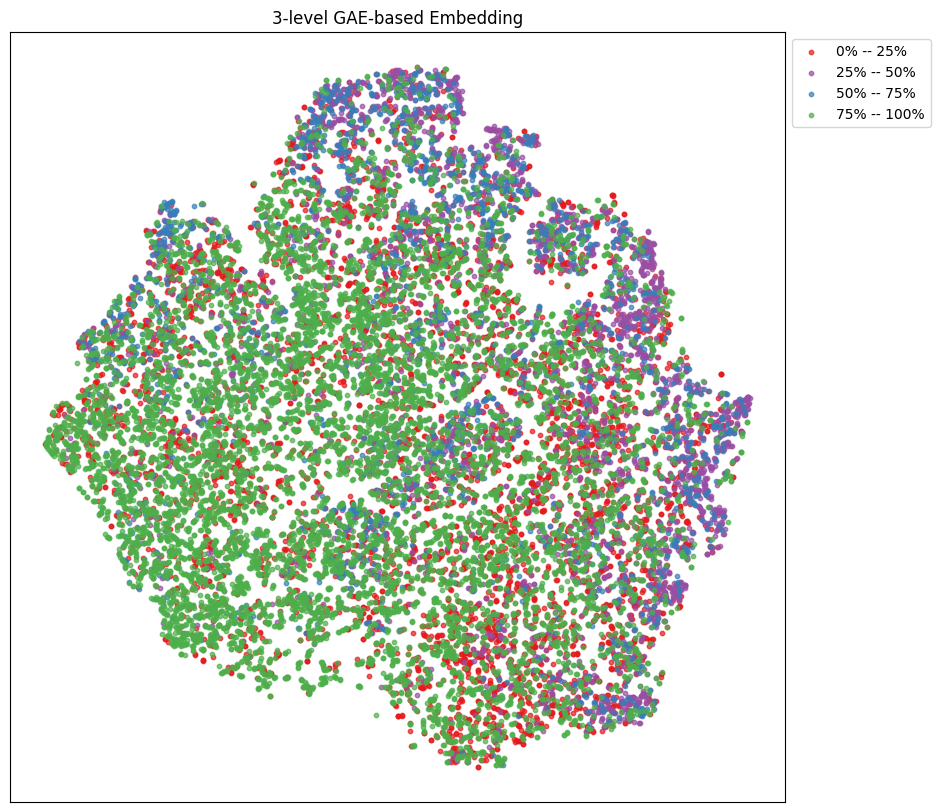

In [38]:
def fit(data, epochs, model):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=0.01)
    for epoch in range(epochs+1):
        optimizer.zero_grad()  # Clear gradients.
        z = model.encode(data.feature, data.edge_index)  # Perform a single forward pass.
        loss = model.recon_loss(z, data.edge_index)
        if epoch%20 == 0:
            print(f"Epoch = {epoch}. Loss = {np.round(loss.detach().numpy(),2)}")
        loss.backward()  # Derive gradients.
        optimizer.step()  # Update parameters based on gradients.
    return z
    

fit(data, 300, gae)
embedding = gae(data.feature, data.edge_index)
visualize(embedding, title = "3-level GAE-based Embedding")

Train classifier using the data from the embedding.

In [39]:
X = embedding.detach().cpu().numpy()
y = data.y.detach().numpy()
est = GradientBoostingClassifier(n_estimators=200, max_depth=3) # n_estimators is the number of trees and max_depth is the maximum depth of any individual tree.
est.fit(X,y)

GradientBoostingClassifier(n_estimators=200)

And show confusion matrix.

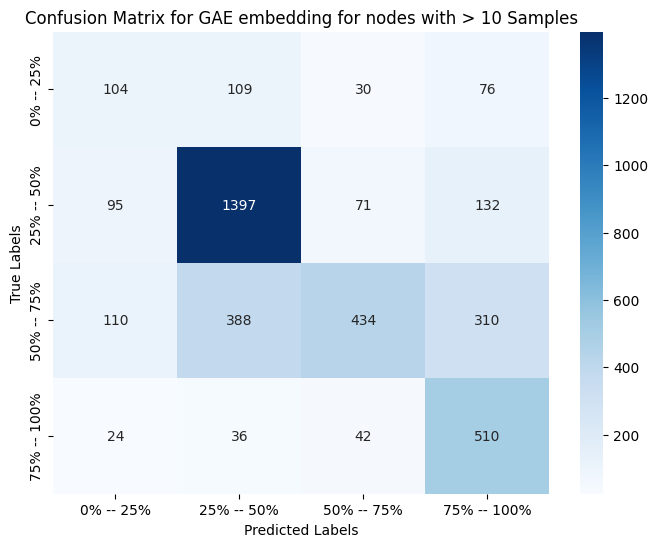

In [40]:
X_confident = [X[node] for node in G.nodes if G.nodes[node]["num_trajectories"] >= 10]
y_confident = [y[node] for node in G.nodes if G.nodes[node]["num_trajectories"] >= 10]
y_pred = est.predict(X_confident)
cm = confusion_matrix(y_confident, y_pred)#, labels = bin_dict.values())
CLIST =  bin_dict.values()

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=CLIST, yticklabels=CLIST)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for GAE embedding for nodes with > 10 Samples')
plt.show() 

It looks like I get a pretty good embedding, at least for the problem with 10 agents, 2 sites with qualities (1, 0.5), and threshold = 0.2.

---

### GraphSAGE -- Prep work ###

I'd like to be able to scale this up, to learn embeddings from incomplete graph data, and if possible, run it in real-time while agents are moving around. My first attempt at scaling up will be to use the GraphSAGE algorithm. 

__Learn about neighbor sampling for mini-batches__

GraphSAGE requires uses mini-batches to enable scaling to very large graphs. The key idea is to use neighbor sampling to form a _batch_, which consists of a subgraph centered around a node. How many neighbors to sample will depend on how connected the graph data is. Let's inspect the degree distribution.

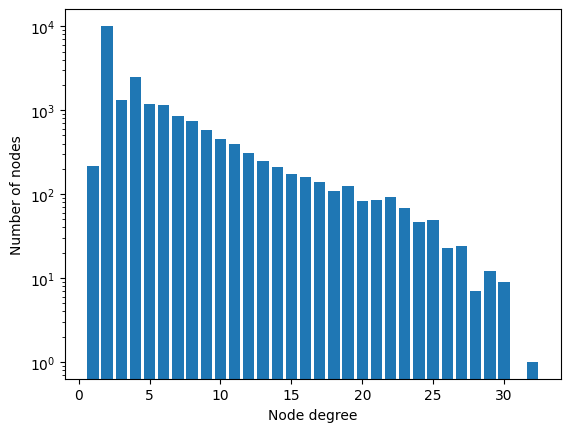

In [41]:
from collections import Counter

degree_list = [y for (x,y) in G.degree]
degree_count = Counter(degree_list)
fig, ax = plt.subplots()
ax.set_xlabel('Node degree')
ax.set_ylabel('Number of nodes')
_ = plt.bar(degree_count.keys(),degree_count.values())

ax.set_yscale('log')

The take away from this plot is that the graph has some highly connected hub nodes, so the random neighborhood sampling from GraphSAGE is a good fit.


See if I can get some sense of what the subgraphs look like when I create some batches. I'll follow the pattern from Maxime's book "Hands-On Graph Neural Networks Using Python"; see pages 130-133.

In [42]:
from torch_geometric.loader import NeighborLoader

train_loader = NeighborLoader(
    data,
    num_neighbors = [10,10,10], # three levels deep
    batch_size = 16,
    input_nodes = data.train_mask,
)

Inspect the batches

In [43]:
for i, subgraph in enumerate(train_loader):
    print(f"Subgraph {i}: {subgraph}")

Subgraph 0: Data(edge_index=[2, 4605], feature=[1548, 100], num_nodes=1548, y=[1548], num_classes=4, train_mask=[1548], test_mask=[1548], n_id=[1548], e_id=[4605], num_sampled_nodes=[4], num_sampled_edges=[3], input_id=[16], batch_size=16)
Subgraph 1: Data(edge_index=[2, 5163], feature=[1750, 100], num_nodes=1750, y=[1750], num_classes=4, train_mask=[1750], test_mask=[1750], n_id=[1750], e_id=[5163], num_sampled_nodes=[4], num_sampled_edges=[3], input_id=[16], batch_size=16)
Subgraph 2: Data(edge_index=[2, 5356], feature=[1943, 100], num_nodes=1943, y=[1943], num_classes=4, train_mask=[1943], test_mask=[1943], n_id=[1943], e_id=[5356], num_sampled_nodes=[4], num_sampled_edges=[3], input_id=[16], batch_size=16)
Subgraph 3: Data(edge_index=[2, 4754], feature=[1639, 100], num_nodes=1639, y=[1639], num_classes=4, train_mask=[1639], test_mask=[1639], n_id=[1639], e_id=[4754], num_sampled_nodes=[4], num_sampled_edges=[3], input_id=[16], batch_size=16)
Subgraph 4: Data(edge_index=[2, 5111], f

Show sample of subgraphs

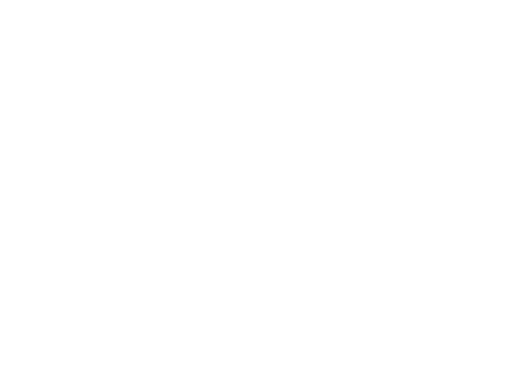

In [45]:
from torch_geometric.utils import to_networkx
for idx, (subdata,pos) in enumerate(zip(train_loader, [221,222,223,224])):
    H = to_networkx (subdata, to_undirected=True)
    ax = fig.add_subplot(pos)
    ax.set_title(f"Subgraph {idx}", fontsize=24)
    plt.axis('off')
    #nx.draw_networkx(H,
    #                 #pos = nx.spring_layout(G, seed=0),
    #                 pos = nx.nx_pydot.graphviz_layout(G, prog="neato"),
    #                 with_labels = False,
    #                 node_color = subdata.y,
    #                 node_size = 10
    #)
    #if idx == 2: break
    #plt.show()


Each subgraph seems to have a something of a hub and spokes-like structure, with the tensors from similar clusters grouping naturally together even without aggregation across multiple hops. That's good because it suggests that there is enough information in the local samples to learn the mapping of the local structures into embeddings that differentiate between the node classes.

---

### 2-Level GraphSAGE ###

The following code is a slightly modified form of the code at the [pytorch_geometric github repository](https://github.com/pyg-team/pytorch_geometric/blob/master/examples/graph_sage_unsup.py). I've split it into different cells to understand it better.

The first cell uses a different neighborhood sampling method than what Maxime used. 

In [75]:
import torch
import torch.nn.functional as F
from sklearn.linear_model import LogisticRegression

import torch_geometric.transforms as T
from torch_geometric.loader import LinkNeighborLoader
from torch_geometric.nn import GraphSAGE


train_loader = LinkNeighborLoader(
    data,
    batch_size=32, # Changed from 256 in github repository code
    shuffle=True,
    neg_sampling_ratio=1.0,
    num_neighbors=[6, 4, 2],
)


What do the batches look like for this different loader?

In [76]:
for i, subgraph in enumerate(train_loader):
    print(f"Subgraph {i}: {subgraph}")

Subgraph 0: Data(edge_index=[2, 4153], feature=[2741, 100], num_nodes=2741, y=[2741], num_classes=4, train_mask=[2741], test_mask=[2741], n_id=[2741], e_id=[4153], num_sampled_nodes=[4], num_sampled_edges=[3], input_id=[32], edge_label_index=[2, 64], edge_label=[64])
Subgraph 1: Data(edge_index=[2, 4130], feature=[2769, 100], num_nodes=2769, y=[2769], num_classes=4, train_mask=[2769], test_mask=[2769], n_id=[2769], e_id=[4130], num_sampled_nodes=[4], num_sampled_edges=[3], input_id=[32], edge_label_index=[2, 64], edge_label=[64])
Subgraph 2: Data(edge_index=[2, 4680], feature=[2977, 100], num_nodes=2977, y=[2977], num_classes=4, train_mask=[2977], test_mask=[2977], n_id=[2977], e_id=[4680], num_sampled_nodes=[4], num_sampled_edges=[3], input_id=[32], edge_label_index=[2, 64], edge_label=[64])
Subgraph 3: Data(edge_index=[2, 4590], feature=[3008, 100], num_nodes=3008, y=[3008], num_classes=4, train_mask=[3008], test_mask=[3008], n_id=[3008], e_id=[4590], num_sampled_nodes=[4], num_sampl

There are way more subgraphs. Why is this?

Do the graphs look different?

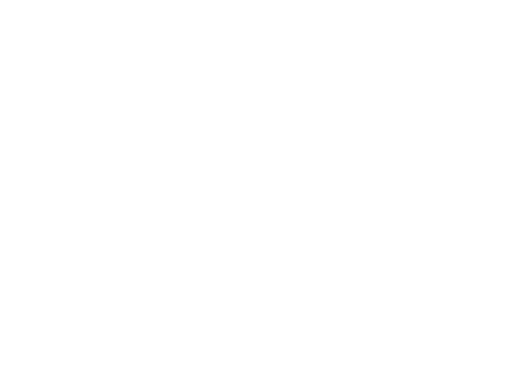

In [77]:
for idx, (subdata,pos) in enumerate(zip(train_loader, [221,222,223,224])):
    H = to_networkx (subdata, to_undirected=True)
    ax = fig.add_subplot(pos)
    ax.set_title(f"Subgraph {idx}", fontsize=24)
    plt.axis('off')
    #nx.draw_networkx(H,
    #                 #pos = nx.spring_layout(G, seed=0),
    #                 pos = nx.nx_pydot.graphviz_layout(G, prog="neato"),
    #                 with_labels = False,
    #                 node_color = subdata.y,
    #                 node_size = 10
    #)
    #if idx == 2: break
    #plt.show()

Yes, the graphs look different. The negative sampling creates some subgraphs not connected to the original. That seems important.

Define the model

In [78]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device, 'feature', 'edge_index')

if model in globals(): del model
model = GraphSAGE(
    #data.num_node_features,
    len(data['feature'][0]),
    hidden_channels=64,
    out_channels = 8,
    num_layers=3,
).to(device)

print(model)

GraphSAGE(100, 8, num_layers=3)


Train the model

In [79]:
import time
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
epochs = 20

def train():
    model.train()

    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        h = model(batch.feature, batch.edge_index)
        h_src = h[batch.edge_label_index[0]]
        h_dst = h[batch.edge_label_index[1]]
        pred = (h_src * h_dst).sum(dim=-1)
        loss = F.binary_cross_entropy_with_logits(pred, batch.edge_label)
        loss.backward()
        optimizer.step()
        total_loss += float(loss) * pred.size(0)

    return total_loss / data.num_nodes


@torch.no_grad()
def test():
    model.eval()
    out = model(data.feature, data.edge_index).cpu()

    clf = LogisticRegression()
    clf.fit(out[data.train_mask], data.y[data.train_mask])
    test_acc = clf.score(out[data.test_mask], data.y[data.test_mask])

    return test_acc


times = []
for epoch in range(1, epochs):
    start = time.time()
    loss = train()
    test_acc = test()
    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Test: {test_acc:.4f}')
    times.append(time.time() - start)
print(f"Median time per epoch: {torch.tensor(times).median():.4f}s")

Epoch: 001, Loss: 4.9711, Test: 0.5086
Epoch: 002, Loss: 4.8245, Test: 0.5065
Epoch: 003, Loss: 4.8304, Test: 0.5119
Epoch: 004, Loss: 4.8414, Test: 0.5262
Epoch: 005, Loss: 4.8171, Test: 0.5143
Epoch: 006, Loss: 4.8860, Test: 0.5234
Epoch: 007, Loss: 4.9490, Test: 0.5119
Epoch: 008, Loss: 4.9174, Test: 0.4944
Epoch: 009, Loss: 4.9239, Test: 0.5012
Epoch: 010, Loss: 4.9166, Test: 0.5033
Epoch: 011, Loss: 4.8602, Test: 0.5103
Epoch: 012, Loss: 4.9211, Test: 0.5044
Epoch: 013, Loss: 4.9433, Test: 0.5206
Epoch: 014, Loss: 4.8955, Test: 0.5105
Epoch: 015, Loss: 4.9293, Test: 0.5140
Epoch: 016, Loss: 4.8868, Test: 0.5016
Epoch: 017, Loss: 4.8698, Test: 0.5145
Epoch: 018, Loss: 4.9379, Test: 0.5107
Epoch: 019, Loss: 4.9012, Test: 0.4925
Median time per epoch: 23.5447s


Visualize

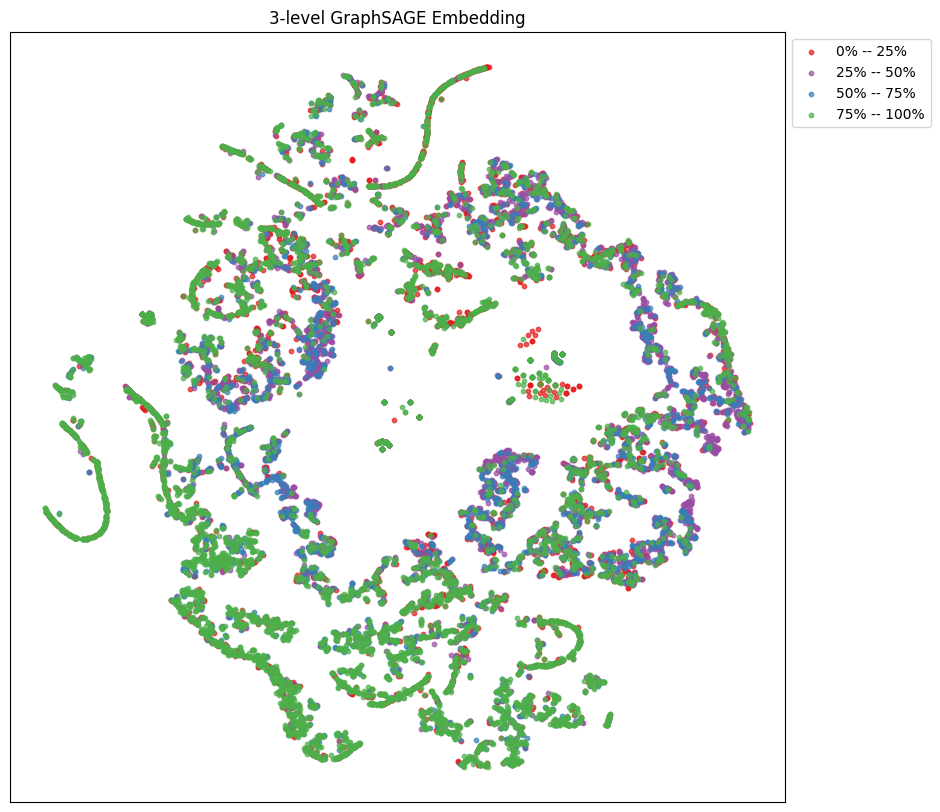

In [80]:
embedding = model(data.feature, data.edge_index)
visualize(embedding, title = "3-level GraphSAGE Embedding")

Use a classifier to evaluate how good the embedding is, though it looks like it will be pretty good given the picture.

In [81]:
X = embedding.detach().cpu().numpy()
y = data.y.detach().numpy()
est = GradientBoostingClassifier(n_estimators=200, max_depth=3) # n_estimators is the number of trees and max_depth is the maximum depth of any individual tree.
est.fit(X,y)

GradientBoostingClassifier(n_estimators=200)

Show confusion matrix.

Text(0.5, 1.0, 'Confusion Matrix for 2-level GraphSage embedding')

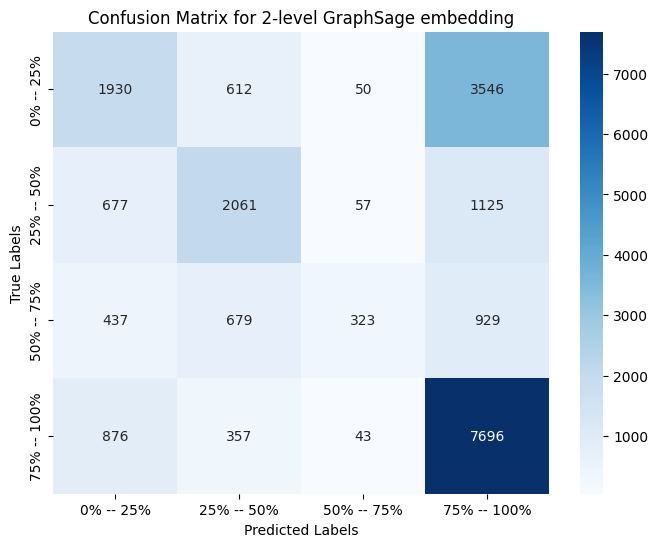

In [82]:
y_pred = est.predict(X)
cm = confusion_matrix(y, y_pred)#, labels = bin_dict.values())
CLIST =  bin_dict.values()

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=CLIST, yticklabels=CLIST)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for 2-level GraphSage embedding')

Show confusion matrix on for data that has been seen often enough to have confidence in.

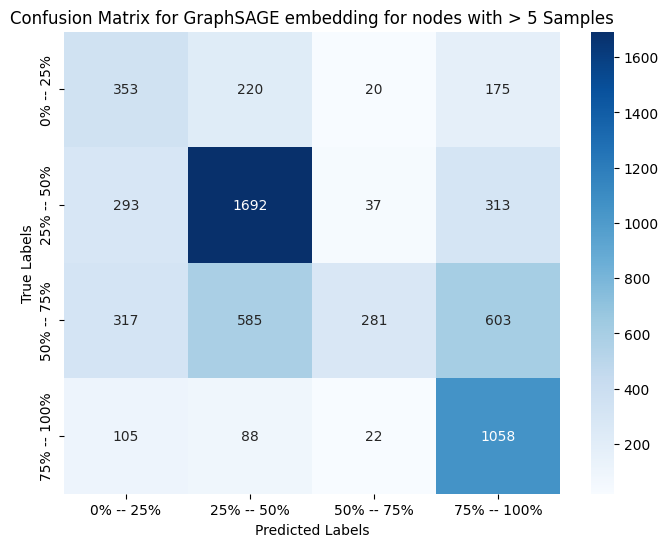

In [83]:
X_confident = [X[node] for node in G.nodes if G.nodes[node]["num_trajectories"] >= 5]
y_confident = [y[node] for node in G.nodes if G.nodes[node]["num_trajectories"] >= 5]
y_pred = est.predict(X_confident)
cm = confusion_matrix(y_confident, y_pred)#, labels = bin_dict.values())
CLIST =  bin_dict.values()

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=CLIST, yticklabels=CLIST)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for GraphSAGE embedding for nodes with > 5 Samples')
plt.show() 

---

Add a trajectory to the visualization. This is only done for 10 agents, 2 sites (1.0, 0.5) quality vector, theta = 0.2, no randomness.

In [84]:
def visualize_with_trajectory(h, trajectory, title = "Scaatter Plot"):
    colorlist = ['#e41a1c', '#984ea3', '#377eb8', '#4daf4a', '#ff7f00', '#ffff33', '#a65628']
    z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())

    plt.figure(figsize=(10,10))
    plt.xticks([])
    plt.yticks([])
    alpha = [0.1 if G.nodes[node]["num_trajectories"] < LOWER_CONFIDENCE else 0.8 for node in G.nodes]
    
    for class_number in range(data.num_classes):
        index_list = extract_nodes_by_class(data.y,class_number)
        #a = [alpha[i] for i in index_list]
        #plt.scatter(z[index_list, 0], z[index_list, 1], s=10, c=colorlist[class_number], alpha = a)
        plt.scatter(z[index_list, 0], z[index_list, 1], s=10, c=colorlist[class_number], alpha = 0.5)

    #plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    _ = plt.legend(bin_dict.values(),bbox_to_anchor=(1, 1), loc='upper left')
    plt.title(title)
    for node in trajectory:
        plt.plot(z[node,0],z[node,1],'kx')
    plt.show()

def extract_nodes_by_class(data,class_number):
    index_list = []
    for index, item in enumerate(data):
        if data[index] == class_number:
            index_list.append(index)
    return index_list

In [85]:
#gat.eval()
#out, embedding = gat(data.feature, data.edge_index)
#file_name = "./pickle_networks/trajectory_actual"
#with open(file_name, 'rb') as f:
#    trajectory = pickle.load(f)
#visualize_with_trajectory(embedding, trajectory, title = "3-level GAT-based Embedding")


---

### To Do ###

See slides beginning at minute 19:50 about preventing overfitting with the classifier, specifically about regularization.

- Tree structure: depth between 4 and 6. Minimize number of leaf nodes.
- Shrinkage: akin to learning rate
- Stochastic graient boosting: randomly sample training data with subsamples, randomly subset features with max_features

Minute 23:26 gives a recipe for selecting parameters via a grid search.

In [86]:
## Only run at the end ... very slow.

from sklearn.model_selection import GridSearchCV # See change from sklearn.grid_search to sklearn.model_selection https://stackoverflow.com/questions/55045351/modulenotfounderror-no-module-named-sklearn-grid-search
param_grid = {'learning_rate': [0.1, 0.05, 0.02, 0.01],
              'max_depth': [4, 6],
              'min_samples_leaf': [3, 5, 9, 17],
              'max_features': [1.0, 0.3, 0.1]}
est = GradientBoostingClassifier(n_estimators = 3000)
#gs_cv = GridSearchCV(est, param_grid).fit(X,y)
# best hyperparameter settings
#gs_cv.best_params